In [3]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
from pyfmreader import loadfile


In [4]:
# article
filename = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_18.05.48.47.tdms'
# file = '/Users/evillz/Data/article/2025_30_5/fcurve___2025.05.30_18.17.35.76.tdms'

In [11]:

file = loadfile(filename, hs3_bool=False)
    # return None

# Check file type


# Get file metadata
filemetadata = file.filemetadata
height_channel_key = filemetadata['height_channel_key']



# Use calibration values from file metadata
file_deflection_sensitivity = filemetadata['defl_sens_nmbyV']  # nm/V
K = filemetadata['spring_const_Nbym']  # N/m
defl_sens = file_deflection_sensitivity / 1e9  # m/V

print (f"Spring constant: {K:.4f} N/m, Deflection sensitivity: {file_deflection_sensitivity:.2f} nm/V")

# Get force curve with parameters from GUI
# z_sensor_delay = params.get('z_sensor_delay', 0.001)
# bool_correct_overshoot = params.get('bool_correct_overshoot', True)
force_curve = file.getcurve(0)
force_curve.preprocess_force_curve(defl_sens, height_channel_key)

# Get segments
# segs = force_curve.get_segments()
# final_nb_points = filemetadata['final_nb_points']
relative_SR = filemetadata['relative_sr']

# Extract retract segment data
for segid, segment in force_curve.get_segments():
    if segment.segment_type in ('Approach', 'App'):
        app_piezo = segment.zheight
        app_deflection = segment.vdeflection * K
        relative_SR_app = relative_SR[segid]
        vel_app_um_s = segment.velocity * 1e06  # Convert from nm to
        time_app = np.arange(len(app_piezo)) * relative_SR_app
    elif segment.segment_type in ('Retract', 'Ret'):
        ret_piezo = segment.zheight
        ret_deflection = segment.vdeflection * K
        relative_SR_ret = relative_SR[segid]
        vel_ret_um_s = segment.velocity * 1e06  # Convert from nm to um/s
        time_ret = np.arange(len(ret_piezo)) * relative_SR_ret 

⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
Spring constant: 0.1400 N/m, Deflection sensitivity: 24.00 nm/V


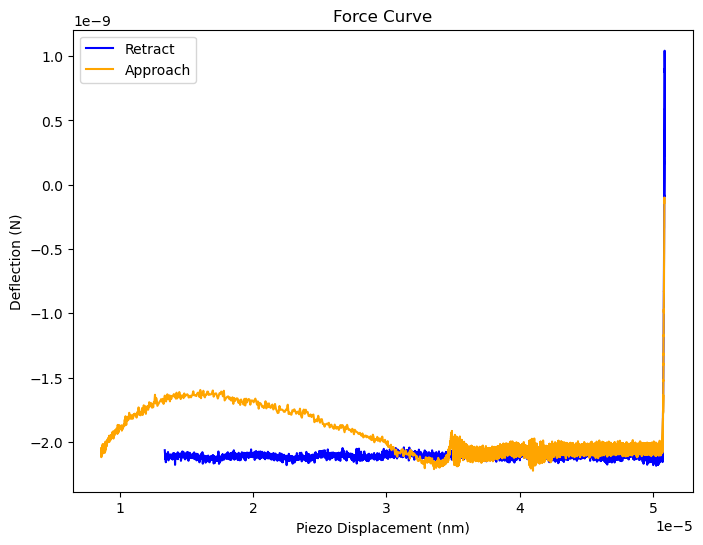

In [12]:
# plot ret_piez vs ret_deflection
plt.figure(figsize=(8, 6))
plt.plot(ret_piezo, ret_deflection, label='Retract', color='blue')
plt.plot(app_piezo, app_deflection, label='Approach', color='orange')
plt.xlabel('Piezo Displacement (nm)')
plt.ylabel('Deflection (N)')
plt.title('Force Curve')
plt.legend()
plt.show()
